<a href="https://colab.research.google.com/github/Naman1232/ML-PROJECTS/blob/main/Time_Series_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
plt.style.use('dark_background')

In [2]:
from google.colab import files
uploaded = files.upload()

Saving AirPassengers.csv to AirPassengers.csv


In [5]:
df = pd.read_csv('AirPassengers.csv')
print(df.head)

<bound method NDFrame.head of        Month  #Passengers
0    1949-01          112
1    1949-02          118
2    1949-03          132
3    1949-04          129
4    1949-05          121
..       ...          ...
139  1960-08          606
140  1960-09          508
141  1960-10          461
142  1960-11          390
143  1960-12          432

[144 rows x 2 columns]>


In [6]:
df['Month'] = pd.to_datetime(df['Month'])
print(df.head)

<bound method NDFrame.head of          Month  #Passengers
0   1949-01-01          112
1   1949-02-01          118
2   1949-03-01          132
3   1949-04-01          129
4   1949-05-01          121
..         ...          ...
139 1960-08-01          606
140 1960-09-01          508
141 1960-10-01          461
142 1960-11-01          390
143 1960-12-01          432

[144 rows x 2 columns]>


In [7]:
df.set_index('Month', inplace=True)
print(df.head())

            #Passengers
Month                  
1949-01-01          112
1949-02-01          118
1949-03-01          132
1949-04-01          129
1949-05-01          121


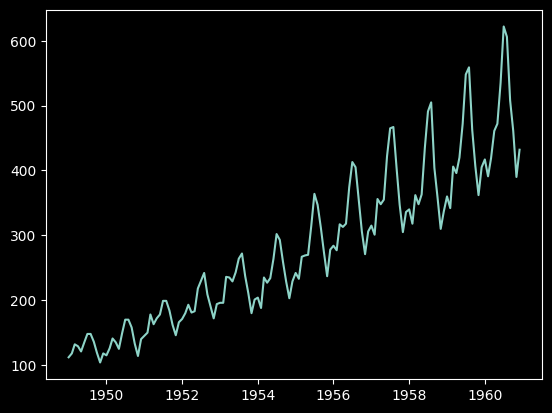

In [9]:
plt.plot(df['#Passengers'])

In [10]:
from statsmodels.tsa.stattools import adfuller
adf, pvalue, usedlag_, nobs_, critical_values_, icbest_ = adfuller(df)
print("pvalue = ", pvalue, " if above 0.05, data is not stationary")

pvalue =  0.991880243437641  if above 0.05, data is not stationary


This code runs the **Augmented Dickey-Fuller (ADF) test** to check if the time series data (`df`) is **stationary** or not.

* It gives a **p-value**.
* If **p-value > 0.05**, the data is **not stationary** (it changes over time).
* If **p-value ≤ 0.05**, the data is **stationary** (stable over time).


In [11]:
df['year'] = [d.year for d in df.index]
df['month'] = [d.strftime('%b') for d in df.index]
years = df['year'].unique()
print(df.head())

            #Passengers  year month
Month                              
1949-01-01          112  1949   Jan
1949-02-01          118  1949   Feb
1949-03-01          132  1949   Mar
1949-04-01          129  1949   Apr
1949-05-01          121  1949   May


<Axes: xlabel='year', ylabel='#Passengers'>

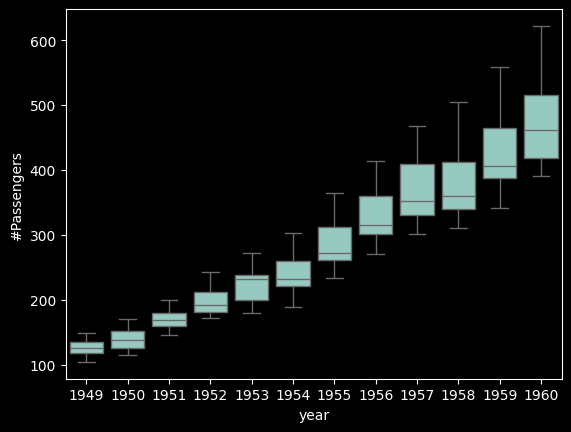

In [15]:
sns.boxplot(x='year', y='#Passengers', data=df)


<Axes: xlabel='month', ylabel='#Passengers'>

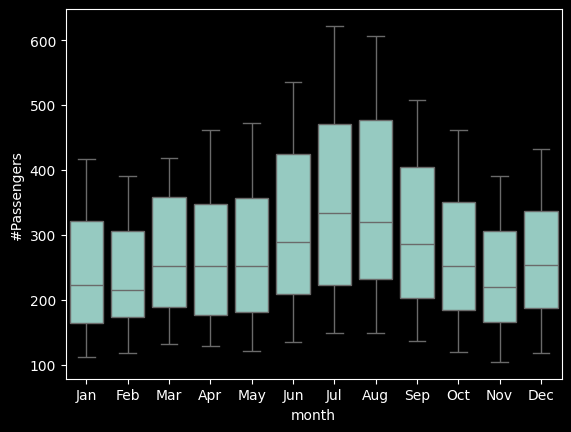

In [14]:
sns.boxplot(x='month', y='#Passengers', data=df)

In [18]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomposed = seasonal_decompose(df['#Passengers'],
                            model ='additive')
trend = decomposed.trend
seasonal = decomposed.seasonal
residual = decomposed.resid

* `seasonal_decompose()` breaks down your time series (`df['#Passengers']`) into three parts:

  1. **Trend:** The long-term upward or downward movement in data (overall direction).

  2. **Seasonal:** The repeating pattern or cycle (like monthly or yearly effects).

  3. **Residual:** What's left after removing trend and seasonality — basically the noise or random fluctuations.

* `model='additive'` means these parts add together to form the original data:

  Original = Trend + Seasonal + Residual

This helps you understand the different components affecting your time series.


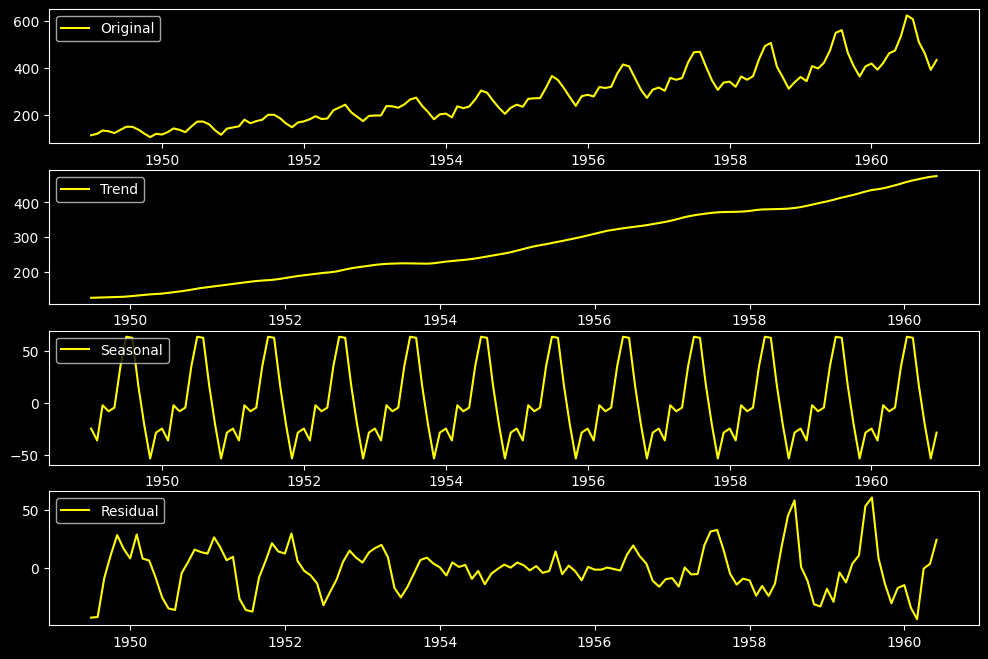

In [20]:
plt.figure(figsize=(12,8))
plt.subplot(411)
plt.plot(df['#Passengers'], label='Original', color='yellow')
plt.legend(loc='upper left')
plt.subplot(412)
plt.plot(trend, label='Trend', color='yellow')
plt.legend(loc='upper left')
plt.subplot(413)
plt.plot(seasonal, label='Seasonal', color='yellow')
plt.legend(loc='upper left')
plt.subplot(414)
plt.plot(residual, label='Residual', color='yellow')
plt.legend(loc='upper left')
plt.show()

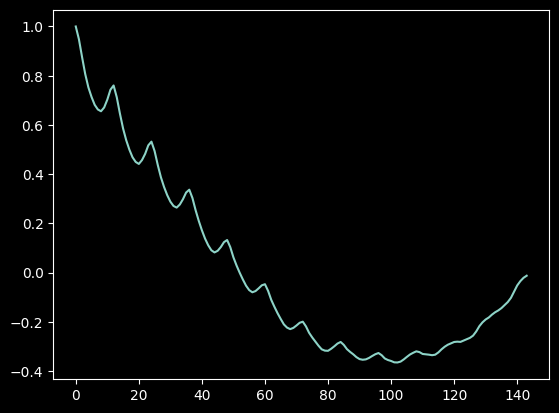

In [23]:
from statsmodels.tsa.stattools import acf
acf_144 = acf(df['#Passengers'], nlags=144)
plt.plot(acf_144)

This code calculates and plots the **autocorrelation function (ACF)** for the "Passengers" data with up to 144 lags (months).

* **acf()**: Measures how much current values relate to past values at different time gaps (lags).
* **nlags=144**: Checks autocorrelation up to 144 time steps back (here, months).
* The plot shows how strong the correlation is between the series and its past values over time.

